In [51]:
#Importing all the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Importing dataset

data = pd.read_csv("D:/CODES/CSV/prices-split-adjusted.csv")
df = pd.DataFrame(data)

In [53]:
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [54]:
df.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [55]:
# showing column wise %ge of NaN values they contains 

for i in df.columns:
  print(i,"\t-\t", df[i].isna().mean()*100)


date 	-	 0.0
symbol 	-	 0.0
open 	-	 0.0
close 	-	 0.0
low 	-	 0.0
high 	-	 0.0
volume 	-	 0.0


<Axes: >

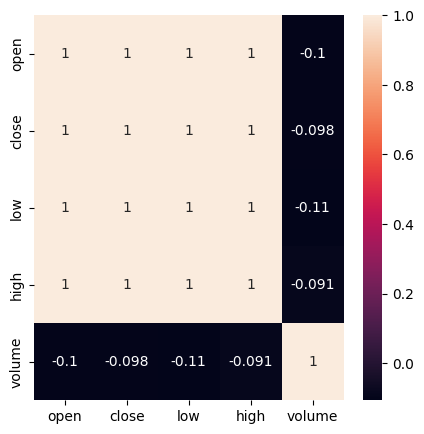

In [57]:
df = df[df['symbol']=='AAP']   # Choosin stock values for any company 

numeric_df = df.select_dtypes(include = ['float64'])

cormap = numeric_df.corr()
fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cormap, annot = True)

In [58]:
def get_corelated_col(cor_dat, threshold): 
  # Cor_data to be column along which corelation to be measured 
  #Threshold be the value above which of corelation to considered
  feature=[]
  value=[]

  for i ,index in enumerate(cor_dat.index):
    if abs(cor_dat[index]) > threshold:
      feature.append(index)
      value.append(cor_dat[index])

  df = pd.DataFrame(data = value, index = feature, columns=['corr value'])
  return df

In [59]:
top_corelated_values = get_corelated_col(cormap['close'], 0.60)
top_corelated_values

,corr value
open,0.999382
close,1.000000
low,0.999615
high,0.999737


In [60]:
df = df[top_corelated_values.index]
df.head()

,open,close,low,high
253,40.700001,40.380001,40.360001,41.040001
720,40.299999,40.139999,39.720001,40.310001
1188,40.049999,40.490002,40.049999,40.779999
1656,39.549999,40.480000,39.549999,40.540001
2124,40.250000,40.639999,40.110001,40.820000


In [61]:
df.shape

(1762, 4)

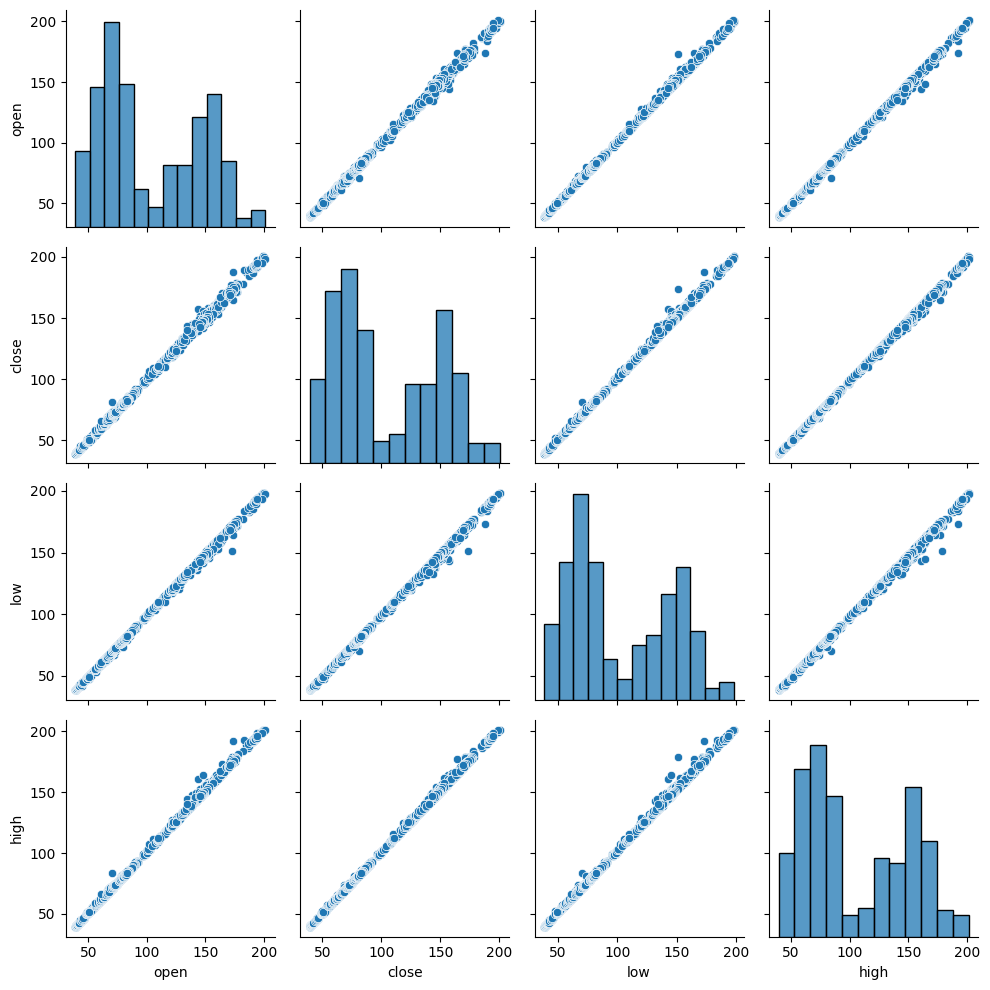

In [62]:
sns.pairplot(df)
plt.tight_layout()

In [63]:
X = df.drop(['close'], axis=1)
y = df['close']

In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.head()

,open,low,high
0,0.012001,0.012392,0.010256
1,0.009539,0.008387,0.005746
2,0.008000,0.010452,0.008649
3,0.004923,0.007323,0.007167
4,0.009231,0.010827,0.008897


In [65]:
#now lets split data in test train pairs

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=False)

Acc = []

In [ ]:
#1.LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

# model training

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
# prediction
y_pred_1 = model_1.predict(X_test)
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_1})
pred_df.head()

,Actual,Predicted
675111,173.660004,173.682489
675608,171.919998,172.593759
676105,172.000000,171.182789
676602,187.789993,187.980305
677099,187.029999,188.440838


In [68]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_1)))
Acc.append(r2_score(y_test, y_pred_1))

Accuracy score of the predictions: 0.9931342019332019


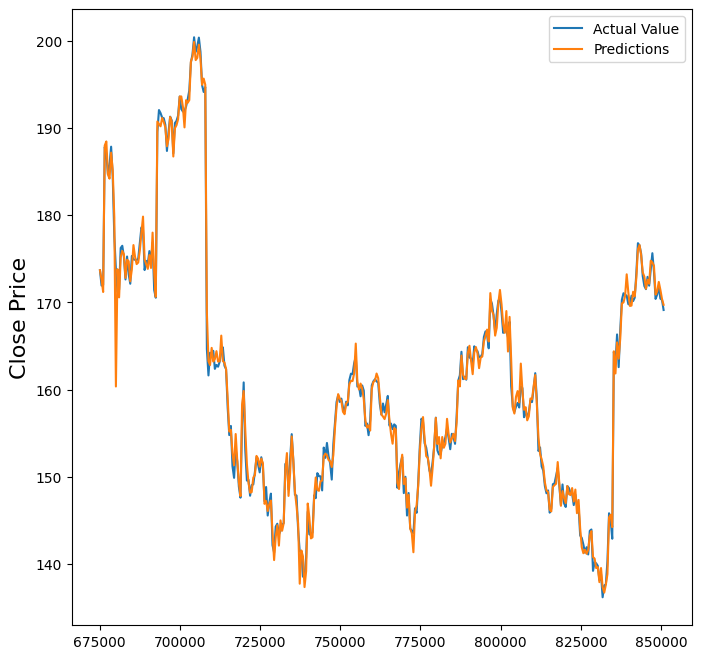

In [69]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [70]:
#2. ANN
# Model Creation

from keras.models import Sequential
from keras.layers import Dense

def regressor(inp_dim):
    
    model = Sequential()
    
    model.add(Dense(20, input_dim=inp_dim, kernel_initializer='normal', activation='relu'))
    model.add(Dense(25, kernel_initializer='normal', activation='relu'))
    model.add(Dense(10, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='normal'))
    
    model.compile(loss='mean_squared_error', optimizer='adam')
    
    return model

In [71]:
# Model Training

model_2 = regressor(inp_dim=3)
model_2.fit(X_train, y_train, epochs=70, validation_split=0.2)

d:\CODES\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6058.2188 - val_loss: 22087.3750
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6047.3706 - val_loss: 22041.5527
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6015.7832 - val_loss: 21877.8496
Epoch 4/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5921.4990 - val_loss: 21406.1094
Epoch 5/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5698.2783 - val_loss: 20341.8418
Epoch 6/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5249.6650 - val_loss: 18363.4785
Epoch 7/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4485.0024 - val_loss: 15226.8086
Epoch 8/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3404.9346 - val_loss: 11031.2705
Epoch 9/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2131.2722 - val_loss: 6529.9087
Epoch 10/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 998.3492 - val_loss: 2925.4978
Epoch 11/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 306.8168 - val_loss: 1019.5228
E

In [72]:
# Prediction

y_pred_2 = model_2.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [73]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_2.flatten()})
pred_df.head()

,Actual,Predicted
675111,173.660004,173.482468
675608,171.919998,171.804932
676105,172.000000,170.029663
676602,187.789993,178.701187
677099,187.029999,187.441757


In [74]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_2)))
Acc.append(r2_score(y_test, y_pred_2))

Accuracy score of the predictions: 0.9848790287200626


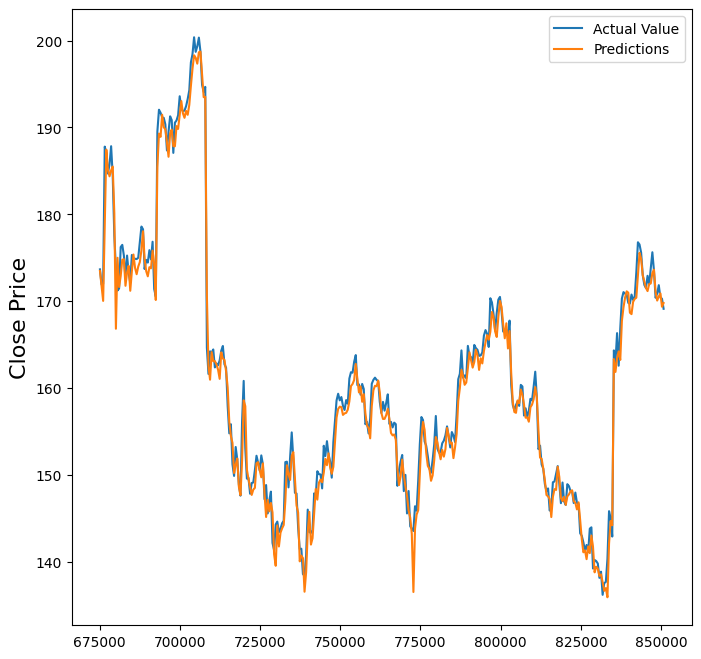

In [75]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [76]:
#3. CNN
X_train = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

In [77]:
from tensorflow.keras import Sequential,utils
from tensorflow.keras.layers import Flatten, Dense, Conv1D, MaxPool1D, Dropout

def reg():
    
    model = Sequential()
    
    model.add(Conv1D(32, kernel_size=(3,), padding='same', activation='relu', input_shape = (X_train.shape[1],1)))
    model.add(Conv1D(64, kernel_size=(3,), padding='same', activation='relu'))
    model.add(Conv1D(128, kernel_size=(5,), padding='same', activation='relu'))
    
    model.add(Flatten())
    
    model.add(Dense(50, activation='relu'))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(units = 1))
    
    model.compile(loss='mean_squared_error', optimizer='adam')
    
    return model

In [78]:
# Model Training

model_3 = reg()
model_3.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


d:\CODES\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5802.1694 - val_loss: 15816.4561
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 930.4299 - val_loss: 616.1285
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.5057 - val_loss: 43.3106
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4756 - val_loss: 29.1133
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1055 - val_loss: 5.4122
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9546 - val_loss: 2.2722
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5449 - val_loss: 2.0073
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4793 - val_loss: 1.7724
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4636 - val_loss: 1.7034
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4579 - val_loss: 1.7037
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4536 - val_loss: 1.7410
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 

In [79]:
# Prediction

y_pred_3 = model_3.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [80]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_3.flatten()})
pred_df.head()

,Actual,Predicted
675111,173.660004,175.673218
675608,171.919998,174.040298
676105,172.000000,172.204834
676602,187.789993,181.001221
677099,187.029999,189.972214


In [81]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_3)))
Acc.append(r2_score(y_test, y_pred_3))

Accuracy score of the predictions: 0.9826304635930961


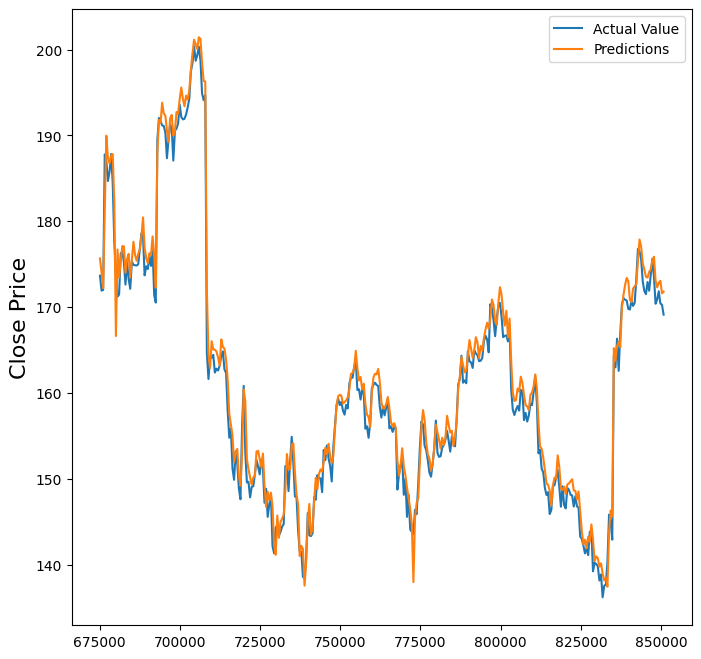

In [82]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

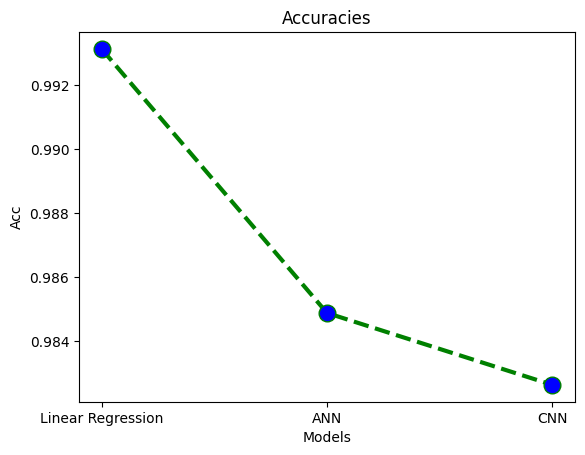

In [83]:
#Comparision of Accuracies of different models
plt.plot(range(3), Acc, color='green', linestyle='dashed', linewidth = 3, 
         marker='o', markerfacecolor='blue', markersize=12) 
plt.ylabel('Acc')
plt.xlabel('Models')
plt.title("Accuracies")
plt.xticks(range(3), ['Linear Regression', 'ANN', 'CNN'])
plt.show()

In [84]:
#Now converting data in a time series data and applying some more models.
close = df.reset_index()['close']
close.head()

0    40.380001
1    40.139999
2    40.490002
3    40.480000
4    40.639999
Name: close, dtype: float64

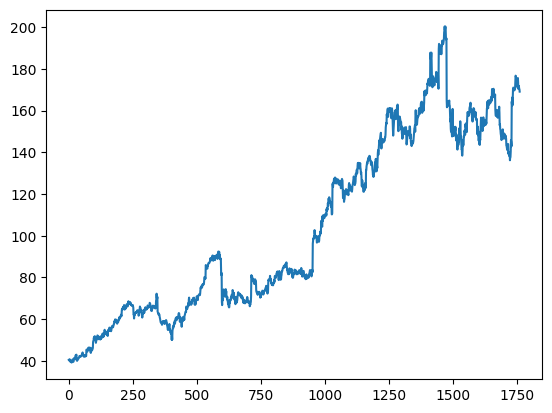

In [85]:
plt.plot(close)
plt.show()

In [86]:
time_step = 30
X, y = [], []

for i in range(len(close)-time_step-1):
    X.append(close[i:(i+time_step)])
    y.append(close[(i+time_step)])

X = np.array(X)
y = np.array(y)

In [87]:
X[:5]

array([[40.380001, 40.139999, 40.490002, 40.48    , 40.639999, 40.240002,
        39.540001, 40.09    , 39.560001, 39.310001, 39.5     , 39.16    ,
        39.23    , 39.740002, 40.5     , 40.549999, 40.59    , 39.77    ,
        39.450001, 40.490002, 41.189999, 41.189999, 40.93    , 40.720001,
        40.810001, 41.57    , 42.330002, 42.549999, 42.810001, 42.630001],
       [40.139999, 40.490002, 40.48    , 40.639999, 40.240002, 39.540001,
        40.09    , 39.560001, 39.310001, 39.5     , 39.16    , 39.23    ,
        39.740002, 40.5     , 40.549999, 40.59    , 39.77    , 39.450001,
        40.490002, 41.189999, 41.189999, 40.93    , 40.720001, 40.810001,
        41.57    , 42.330002, 42.549999, 42.810001, 42.630001, 42.880001],
       [40.490002, 40.48    , 40.639999, 40.240002, 39.540001, 40.09    ,
        39.560001, 39.310001, 39.5     , 39.16    , 39.23    , 39.740002,
        40.5     , 40.549999, 40.59    , 39.77    , 39.450001, 40.490002,
        41.189999, 41.189999, 40.93 

In [88]:
y[:5]

array([42.880001, 40.150002, 40.      , 40.240002, 40.220001])

In [89]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.007567,0.006079,0.008250,0.008188,0.009180,0.006699,0.002357,0.005769,0.002481,0.000930,...,0.007420,0.007420,0.005799,0.004489,0.005051,0.009789,0.014528,0.015900,0.017521,0.016399
1,0.006079,0.008250,0.008188,0.009180,0.006699,0.002357,0.005769,0.002481,0.000930,0.002109,...,0.007420,0.005799,0.004489,0.005051,0.009789,0.014528,0.015900,0.017521,0.016399,0.017957
2,0.008250,0.008188,0.009180,0.006699,0.002357,0.005769,0.002481,0.000930,0.002109,0.000000,...,0.005799,0.004489,0.005051,0.009789,0.014528,0.015900,0.017521,0.016399,0.017957,0.000935
3,0.008188,0.009180,0.006699,0.002357,0.005769,0.002481,0.000930,0.002109,0.000000,0.000434,...,0.004489,0.005051,0.009789,0.014528,0.015900,0.017521,0.016399,0.017957,0.000935,0.000000
4,0.009180,0.006699,0.002357,0.005769,0.002481,0.000930,0.002109,0.000000,0.000434,0.003598,...,0.005051,0.009789,0.014528,0.015900,0.017521,0.016399,0.017957,0.000935,0.000000,0.001496


In [90]:
#PREDICTION
#now lets split data in test train pairs
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=False)

Acc = []

In [91]:
#1. LSTM
X_train_ = X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test_ = X_test.reshape(X_test.shape[0],X_test.shape[1],1)

In [92]:
from tensorflow.keras.layers import LSTM

def Reg():
    model = Sequential()
    
    model.add(LSTM(70, return_sequences=True, input_shape=(30,1)))
    model.add(LSTM(70, return_sequences=True))
    model.add(LSTM(70))
    model.add(Dense(1))
    
    model.compile(loss='mean_squared_error', optimizer='adam')
    
    return model

In [93]:
# Model Training

model_1 = reg()
model_1.fit(X_train_, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


d:\CODES\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2682.6909 - val_loss: 303.1308
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 81.4680 - val_loss: 98.8976
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18.0673 - val_loss: 42.0158
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.3267 - val_loss: 40.3665
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.6159 - val_loss: 31.1027
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.9230 - val_loss: 44.8455
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.7479 - val_loss: 32.6744
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.9189 - val_loss: 32.7271
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.6584 - val_loss: 31.6468
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.3559 - val_loss: 47.8756
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.1090 - val_loss: 30.2376
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms

In [94]:
# Prediction

y_pred_1 = model_1.predict(X_test_)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [95]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_1.flatten()})
pred_df.head()

,Actual,Predicted
0,184.690002,186.786209
1,185.770004,188.686081
2,187.839996,189.351868
3,184.449997,190.645233
4,177.539993,190.592926


In [96]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_1)))
Acc.append(r2_score(y_test, y_pred_1))

Accuracy score of the predictions: 0.804298034223352


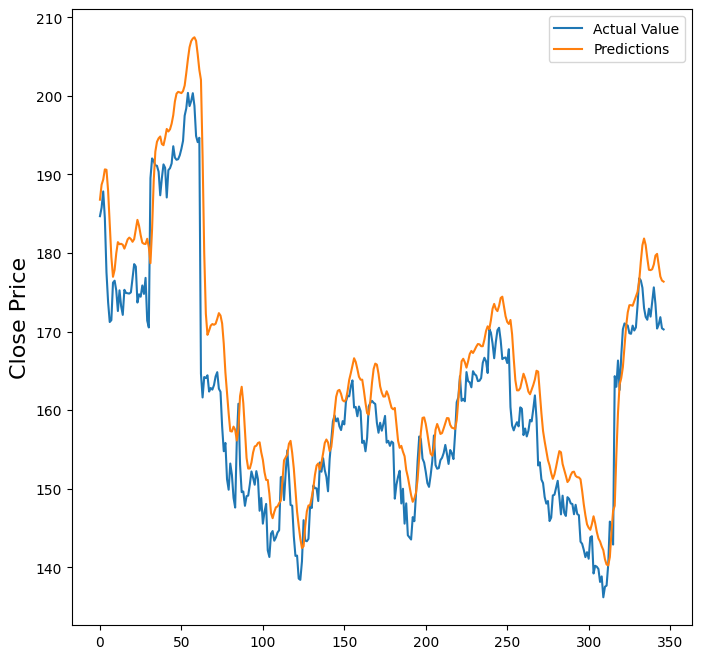

In [97]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [98]:
#2. ANN
# Model Training

model_2 = regressor(inp_dim=30)
model_2.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


d:\CODES\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6283.5308 - val_loss: 22400.4609
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6247.3325 - val_loss: 21992.0645
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5975.4316 - val_loss: 19398.5312
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4864.1172 - val_loss: 11268.9482
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2444.3005 - val_loss: 1001.3108
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 466.8113 - val_loss: 1562.7267
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 228.5069 - val_loss: 1623.4154
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 219.6215 - val_loss: 1411.5293
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 209.8540 - val_loss: 1410.9144
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 200.4743 - val_loss: 1332.3188
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 191.6878 - val_loss: 1301.0045
Epoch 12/10

In [99]:
# Prediction

y_pred_2 = model_2.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [100]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_2)))
Acc.append(r2_score(y_test, y_pred_2))

Accuracy score of the predictions: 0.8057720348131764


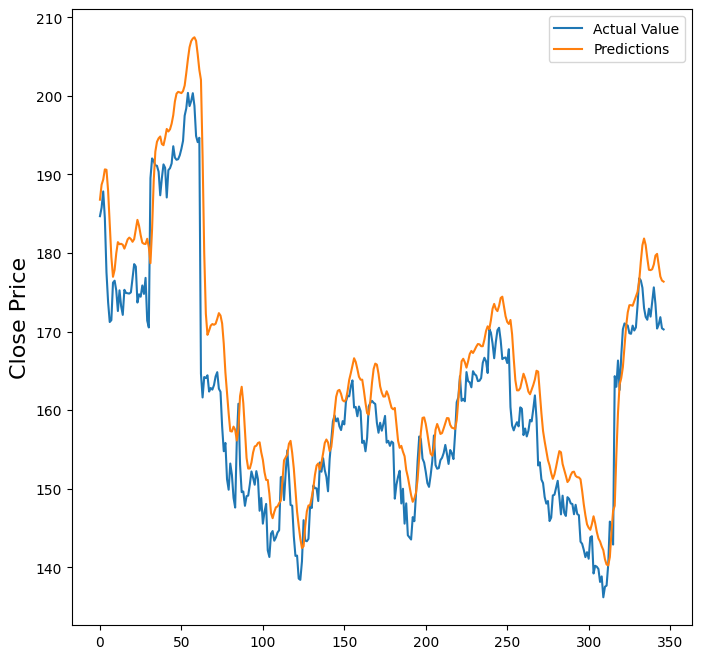

In [101]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [102]:
#3. CNN
# Model Training

model_3 = reg()
model_3.fit(X_train_, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


d:\CODES\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 3187.0679 - val_loss: 273.0608
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 89.5313 - val_loss: 208.1940
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.6391 - val_loss: 49.4924
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.1236 - val_loss: 41.5023
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.4011 - val_loss: 31.8218
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.8115 - val_loss: 46.5004
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.3553 - val_loss: 46.6071
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.3600 - val_loss: 43.0787
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.3210 - val_loss: 32.8357
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.0569 - val_loss: 50.7139
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.8705 - val_loss: 42.3634
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

In [105]:
# Prediction

y_pred_3 = model_3.predict(X_test_)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [106]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_3.flatten()})
pred_df.head()

,Actual,Predicted
0,184.690002,181.873795
1,185.770004,181.870865
2,187.839996,182.778702
3,184.449997,184.419357
4,177.539993,183.599503


In [107]:
# Measure the Accuracy Score

from sklearn.metrics import r2_score
 
print("Accuracy score of the predictions: {0}".format(r2_score(y_test, y_pred_3)))
Acc.append(r2_score(y_test, y_pred_3))

Accuracy score of the predictions: 0.9171533690890181


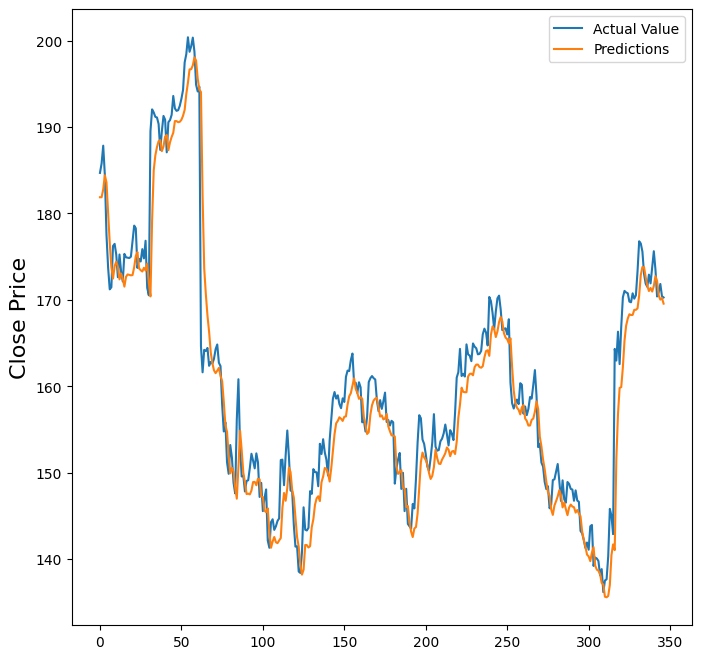

In [108]:
plt.figure(figsize=(8,8))
plt.ylabel('Close Price', fontsize=16)
plt.plot(pred_df)
plt.legend(['Actual Value', 'Predictions'])
plt.show()

In [109]:
#Comparision of Accuracies of different models


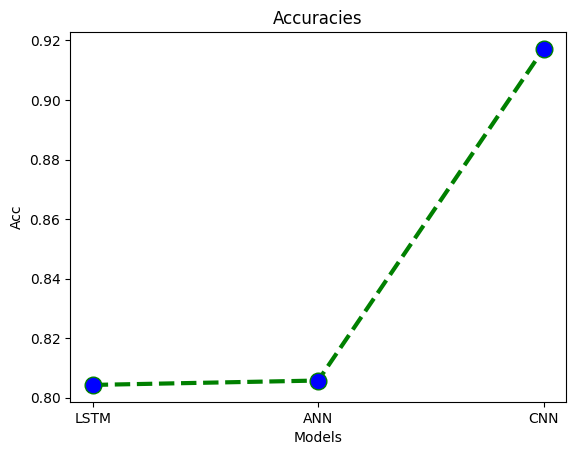

In [110]:
plt.plot(range(3), Acc, color='green', linestyle='dashed', linewidth = 3, 
         marker='o', markerfacecolor='blue', markersize=12) 
plt.ylabel('Acc')
plt.xlabel('Models')
plt.title("Accuracies")
plt.xticks(range(3), ['LSTM', 'ANN', 'CNN'])
plt.show()

In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv1D
import warnings

# Suppress Keras warnings for a cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='keras')

# --- 1. Setup: Load and Filter Data ---
print("Loading data...")
try:
    data = pd.read_csv("prices-split-adjusted.csv")
except FileNotFoundError:
    print("Error: 'prices-split-adjusted.csv' not found. Please place it in the same directory.")
    exit()

df = data[data['symbol'] == 'AAP']
print("Data loaded and filtered for 'AAP' ticker.\n")


# ==============================================================================
# --- Scenario 1: Predicting Today's Close (Multi-Feature Linear Regression) ---
# ==============================================================================
print("--- SCENARIO 1: Same-Day Prediction using Linear Regression ---")

# a) Prepare data and train the model
df_scenario1 = df[['open', 'low', 'high', 'close']]
X1 = df_scenario1.drop(['close'], axis=1)
y1 = df_scenario1['close']

# The scaler will learn this specific column order: ['open', 'low', 'high']
multi_feature_scaler = MinMaxScaler()
X1_scaled = multi_feature_scaler.fit_transform(X1)

X_train1, _, y_train1, _ = train_test_split(X1_scaled, y1, test_size=0.2, shuffle=False)

lr_model = LinearRegression()
lr_model.fit(X_train1, y_train1)
print("Linear Regression model trained.")

# b) Make a new prediction
print("\n--- Making a New Prediction for Scenario 1 ---")
# New data point for the day
new_data_s1 = {
    'open': [190.50],
    'low': [189.70],  # CORRECTED ORDER: 'low' comes before 'high'
    'high': [192.30]
}
# Ensure the DataFrame is created with the correct column order
new_df_s1 = pd.DataFrame(new_data_s1, columns=['open', 'low', 'high'])

# Scale the new data using the FITTED 'multi_feature_scaler'
new_data_scaled_s1 = multi_feature_scaler.transform(new_df_s1)

# Predict
predicted_price_s1 = lr_model.predict(new_data_scaled_s1)
print(f"\nNew Data for Scenario 1:\n{new_df_s1}")
print(f"--> Predicted Close Price: ${predicted_price_s1[0]:.2f}\n")


# ==============================================================================
# --- Scenario 2: Forecasting Tomorrow's Close (Time-Series CNN) ---
# ==============================================================================
print("\n--- SCENARIO 2: Forecasting Next Day's Close using CNN ---")

# a) Prepare data and train the model
close_prices = df.reset_index()['close']
time_step = 30
X2, y2 = [], []
for i in range(len(close_prices) - time_step - 1):
    X2.append(close_prices[i:(i + time_step)])
    y2.append(close_prices[(i + time_step)])

X2, y2 = np.array(X2), np.array(y2)

time_series_scaler = MinMaxScaler()
X2_scaled = time_series_scaler.fit_transform(X2)

X_train2, _, y_train2, _ = train_test_split(X2_scaled, y2, test_size=0.2, shuffle=False)
X_train2_cnn = X_train2.reshape(X_train2.shape[0], X_train2.shape[1], 1)

# Define and train the CNN model
cnn_model = Sequential([
    Conv1D(32, kernel_size=(3), padding='same', activation='relu', input_shape=(time_step, 1)),
    Conv1D(64, kernel_size=(3), padding='same', activation='relu'),
    Conv1D(128, kernel_size=(5), padding='same', activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(20, activation='relu'),
    Dense(units=1)
])
cnn_model.compile(loss='mean_squared_error', optimizer='adam')
print("Training CNN model (this may take a moment)...")
cnn_model.fit(X_train2_cnn, y_train2, epochs=100, validation_split=0.2, verbose=0)
print("CNN model trained.")

# b) Make a new prediction
print("\n--- Making a New Prediction for Scenario 2 ---")
last_30_days_close = np.array([
    
61.53,
61.17,
60.57,
60.82,
60.51,
59.33,
59.28,
59.15,
58.53,
58.83,
57.66,
60.03,
61.66,
63.15,
60.88,
60.43,
59.57,
58.92,
58.14,
60.13,
59.79,
58.63,
57.88,
59.23,
60.25,
60.05,
60.03,
59.37,
57.37,
55.56

]).reshape(1, -1)

new_data_scaled_s2 = time_series_scaler.transform(last_30_days_close)
new_data_reshaped_s2 = new_data_scaled_s2.reshape(1, time_step, 1)

predicted_scaled_price = cnn_model.predict(new_data_reshaped_s2)

dummy_array = np.zeros((1, time_step))
dummy_array[:, 0] = predicted_scaled_price.flatten()
predicted_price_actual = time_series_scaler.inverse_transform(dummy_array)[0, 0]

print(f"\nInput Sequence for Scenario 2 (last 30 days' close prices):\n {last_30_days_close.flatten()}")
print(f"--> Predicted Close Price for Tomorrow: ${predicted_price_actual:.2f}")

Loading data...
Data loaded and filtered for 'AAP' ticker.

--- SCENARIO 1: Same-Day Prediction using Linear Regression ---
Linear Regression model trained.

--- Making a New Prediction for Scenario 1 ---

New Data for Scenario 1:
    open    low   high
0  190.5  189.7  192.3
--> Predicted Close Price: $191.30


--- SCENARIO 2: Forecasting Next Day's Close using CNN ---
Training CNN model (this may take a moment)...
CNN model trained.

--- Making a New Prediction for Scenario 2 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

Input Sequence for Scenario 2 (last 30 days' close prices):
 [61.53 61.17 60.57 60.82 60.51 59.33 59.28 59.15 58.53 58.83 57.66 60.03
 61.66 63.15 60.88 60.43 59.57 58.92 58.14 60.13 59.79 58.63 57.88 59.23
 60.25 60.05 60.03 59.37 57.37 55.56]
--> Predicted Close Price for Tomorrow: $9295.60
